In [63]:
import numpy as np
import pandas as pd
import random
from EMDPM.model_generator import generate_logistic_model
from EMDPM.synthetic_data_generator import generate_synthetic_data
from EMDPM.visualization import (
    plot_biomarker_trajectories,
    plot_true_observations,
    plot_initial_beta_guess,
    plot_theta_fit_comparison,
    plot_theta_error_history,
    plot_beta_overlay,
    plot_beta_error_history,
    plot_lse,
    plot_cog_regression_history
)
from EMDPM.utils import *
from EMDPM.em_transformer_rework import EM

true x0: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
true f: [0.         0.01123988 0.01207819 0.01155182 0.02688619 0.
 0.01019029 0.         0.         0.        ]
a = 1.8531667261047913, b = 1.5312904682995265


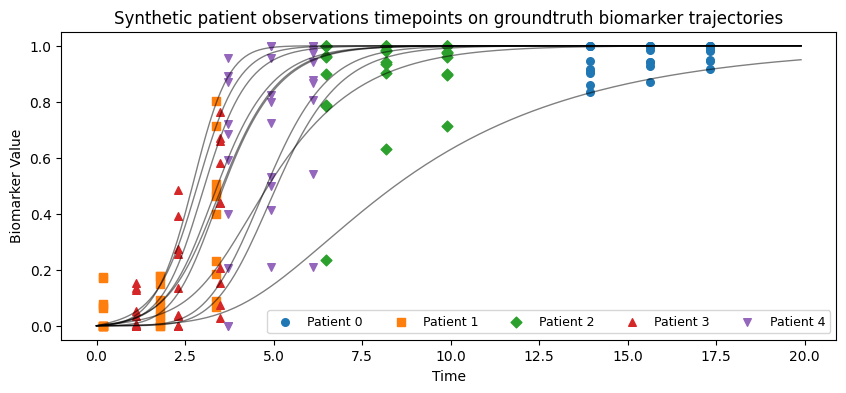

(600,)


In [64]:
# params
n_biomarkers = 10
t_max = 20
t_span = np.linspace(0, t_max, 8000)
noise_level = 0.1
n_patients = 200
n_patient_obs = 3

# fit and transform
t, x_true, K, x0, f, scalar_K  = generate_logistic_model(n_biomarkers=n_biomarkers, t_max=t_max)

df, cog_a, cog_b = generate_synthetic_data(
    n_biomarkers = n_biomarkers,
    t_max = t_max, 
    noise_level = noise_level,
    n_patients = n_patients,
    n_patient_obs = n_patient_obs,
    x_true=x_true, 
    t=t,
)
#plot_biomarker_trajectories(t, x_true, n_biomarkers=n_biomarkers)
plot_true_observations(df, t, x_true)

biomarker_cols = [col for col in df.columns if col.startswith("biomarker_")]

X_obs = df[biomarker_cols].values       # (n_obs, n_biomarkers)
dt = df["dt"].values                # (n_obs,)
ids = df["patient_id"].values       # (n_obs,)
cog = df["cognitive_score"].values  # (n_obs,)
beta_true = df["beta_true"].values 

print(beta_true.shape)

beta_true = beta_true[::3]

f_init = initialize_f_eigen(K, n_eigs=2)
f_init = f_init[0]

# print(X.shape, dt.shape, ids.shape, cog.shape, beta_true.shape)

def create_patient_list(X_obs, ids, dt, cog, initial_beta=None):
    unique_ids = np.unique(ids)
    id_to_index = {pid: idx for idx, pid in enumerate(unique_ids)}

    patient_list = []
    for pid in unique_ids:
        mask = (ids == pid)
        patient_data = {
            "id": pid,
            "X_obs": X_obs[mask],
            "dt": dt[mask],
            "cog": cog[mask],
            
        }
        if initial_beta is not None:
            patient_data["initial_beta"] = initial_beta[id_to_index[pid]]
        patient_list.append(patient_data)

    return patient_list

X = create_patient_list(X_obs, ids, dt, cog, initial_beta=None)
#X_train, X_val = train_test_split(X, test_size=0.2, random_state=75)

#print(X[0])

In [65]:
best_em = EM(max_iter=20,
             t_max=20,
             K=K,
             lambda_f=0.545,
             lambda_cog=0.0,
             lambda_scalar=0.2,
             jac_toggle=True,
             epsilon=1e-4,
             initial_f=f_init)

best_em.fit(X=X, y=None)

  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [02:40<00:00,  8.02s/it]


EM(K=array([[0.        , 0.20318355, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.20318355, 0.        , 0.35148169, 0.08339606, 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.35148169, 0.        , 0.43009017, 0.39584093,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.08339606, 0.43009017, 0.        , 0.17905726,
        0.38982962, 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.39584093, 0.17905726, 0.        ,
        1.        , 0.22111085, 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.38982962, 1.        ,
        0.        , 0.91113057, 0.48673754, 0.        , 0.        ],
       [0.        , 0.        , 0.        ,...
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.2992669 , 0.83920955, 0.        ]]),
   epsilon=0.0001,
   initial_f=array([0.00000000e+00, 6.23751662e-02, 1.60519818e-01, 2.79701593e-01,
       5.91951513e-01, 6.80889289e-01, 4.39047857e-01, 2.25747107e-01,
       9.73044352e-02, 6.70936641e-04]),
   jac_toggle=True, lambda_cog=0.0, lambda_f=0.545, lambda_scalar=0.2,
   max_iter=20, rng=Generator(PCG64) at 0x7F770DECCAC0, t_max=20)

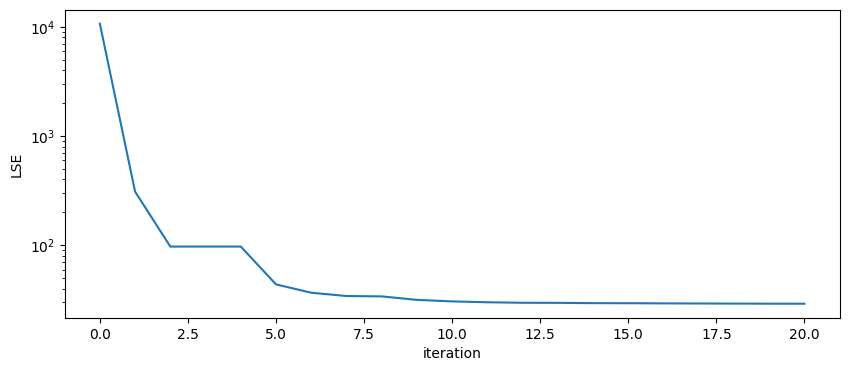

29.226120220622267


In [66]:

theta_coarse = best_em.theta_history[:,-1]
plot_lse(best_em.lse_history)
print(best_em.lse_history[-1])

<bound method BaseEstimator.get_params of EM(K=array([[0.        , 0.20318355, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.20318355, 0.        , 0.35148169, 0.08339606, 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.35148169, 0.        , 0.43009017, 0.39584093,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.08339606, 0.43009017, 0.        , 0.17905726,
        0.38982962, 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.39584093, 0.17905726, 0.        ,
        1.        , 0.22111085, 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.38982962, 1.        ,
        0.        , 0.91113057, 0.48673754, 0.        , 0.        ],
       [0.        , 0.        , 0.        ,...
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.      

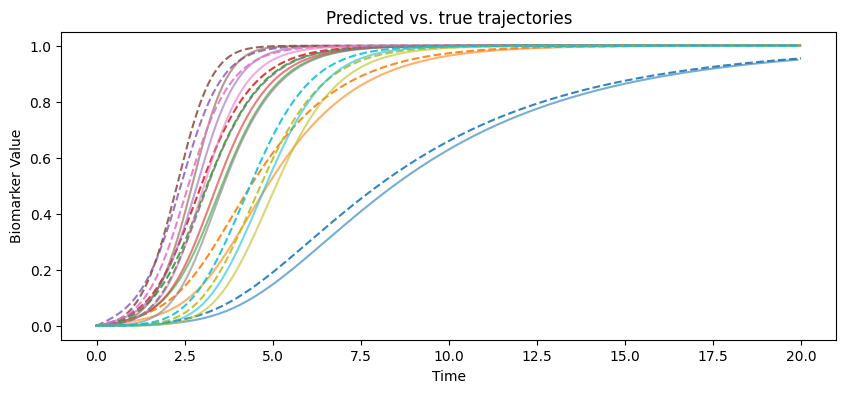

In [67]:
f_true = f 
s_true = np.ones(n_biomarkers)
scalar_K_true = 1.0 

#best_em = grid.best_estimator_

#plot_initial_beta_guess(df, em_model_0.beta_iter_, t, x_true)
# histories
theta_history = best_em.theta_history
beta_history = best_em.beta_history
lse_history = best_em.lse_history

# final params
final_theta = theta_history[:,-1]
final_x0 = np.zeros(n_biomarkers)
final_f = final_theta[0:n_biomarkers]
final_s = final_theta[n_biomarkers:2*n_biomarkers]
final_scalar_K = final_theta[-1]
final_model = solve_system(final_x0, final_f, K, t_span, final_scalar_K)

# initial parameters
initial_theta = theta_history[:,0]
initial_x0 = np.zeros(n_biomarkers)
initial_f = initial_theta[:n_biomarkers]
initial_s = initial_theta[n_biomarkers:2*n_biomarkers]
initial_scalar_K = initial_theta[-1]

scaled_final_model = np.zeros_like(final_model)
for idx, s in enumerate(final_s):
    scaled_final_model[idx, :] = s * final_model[idx, :]

initial_model = solve_system(initial_x0, initial_f, K, t_span, initial_scalar_K)

# plotting
print(best_em.get_params)
plot_theta_fit_comparison(t, t_span, x_true, initial_model, final_model, n_biomarkers)
#plot_beta_overlay(df, beta_iter=, em_model_0.theta_iter_, t_span, n_biomarkers, x_init, x_final, iteration=em_model_0.num_iterations - 1)
#plot_beta_error_history(beta_history, em_model_0.num_iterations)
#plot_lse(lse_history)
#plot_cog_regression_history(em_model_0.cog_regression_history_)



In [68]:
print("THETA SUMMARY:")
print("true theta:")
print("f: ", np.round(f_true, 3))
print("s: ", np.round(s_true, 3))
print("s_k: ", scalar_K_true)

print("final theta:")
print("f: ", np.round(final_theta[:n_biomarkers], 3))
print("s: ", np.round(final_theta[n_biomarkers:2*n_biomarkers], 3))
print("s_k: ", final_theta[-1])

## Beta comparison:
print("\nBETA SUMMARY:")
beta_true = beta_true[::3]
print("beta true: ",np.round(beta_true,3))
print("beta final: ", np.round(beta_history[0:10,-1], 3))

THETA SUMMARY:
true theta:
f:  [0.    0.011 0.012 0.012 0.027 0.    0.01  0.    0.    0.   ]
s:  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
s_k:  1.0
final theta:
f:  [0.    0.02  0.012 0.025 0.057 0.    0.026 0.007 0.    0.   ]
s:  [0.971 0.963 0.969 0.961 0.956 0.961 0.962 0.96  0.963 0.961]
s_k:  0.9930276734018273

BETA SUMMARY:
beta true:  [13.948  1.122 11.646 11.704  2.673 12.008  1.983  9.937  0.228  8.34
 12.663  8.312 13.954 11.014  0.53   0.489  4.007  6.277 12.963 12.64
  9.125  1.389 10.366  4.832  6.203  7.234 10.825  3.833  7.669 15.335
  0.64   3.427  1.749  6.795  8.771  5.319 10.502  7.49  11.57   0.402
  2.704 12.987 11.233  9.047  6.686 10.157  7.011  5.422  4.122  0.372
 11.111 12.802  5.682  7.038 13.552  4.359 15.905  8.846 14.881  9.151
  9.382 16.032 14.892 13.666  4.502  9.431  3.113]
beta final:  [16.631  0.     6.777  0.775  3.499 13.52  13.138  7.281 13.007  9.913]


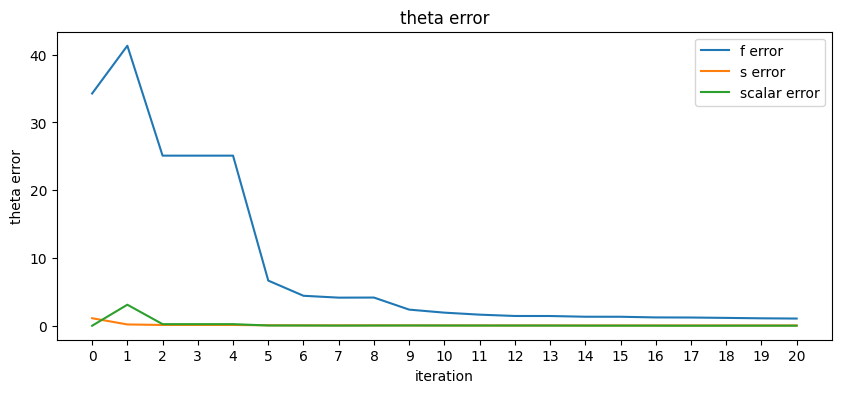

In [69]:
import matplotlib.pyplot as plt

def plot_theta_error_history(theta_history: np.ndarray, n_biomarkers: int,
                             f_true: np.ndarray, s_true: np.ndarray, scalar_K_true: float) -> None:
    """
    Plots normalized error of each parameter group over EM iterations.
    """
    num_iterations = theta_history.shape[1]
    f_error_history = []
    s_error_history = []
    scalar_K_error_history = []

    for iteration in range(num_iterations):
        theta = theta_history[:,iteration]

        f_est = theta[0:n_biomarkers]
        s_est = theta[n_biomarkers:2*n_biomarkers]
        scalar_K_est = theta[-1]

        f_err = np.mean(np.abs(f_true - f_est)) / (np.mean(np.abs(f_true)) + 1e-8)
        s_err = np.mean(np.abs(s_true - s_est)) / (np.mean(np.abs(s_true)) + 1e-8)
        k_err = np.abs(scalar_K_true - scalar_K_est) / (np.abs(scalar_K_true) + 1e-8)

        f_error_history.append(f_err)
        s_error_history.append(s_err)
        scalar_K_error_history.append(k_err)
        
    plt.figure(figsize=(10, 4))
    plt.plot(f_error_history, label="f error")
    plt.plot(s_error_history, label="s error")
    plt.plot(scalar_K_error_history, label="scalar error")
    plt.xticks(range(0,num_iterations))
    plt.title("theta error")
    plt.xlabel("iteration")
    plt.ylabel("theta error")
    plt.legend()
    plt.show()
    
plot_theta_error_history(theta_history=theta_history, n_biomarkers=n_biomarkers,
                         f_true=f, s_true=np.ones(n_biomarkers), scalar_K_true=scalar_K)

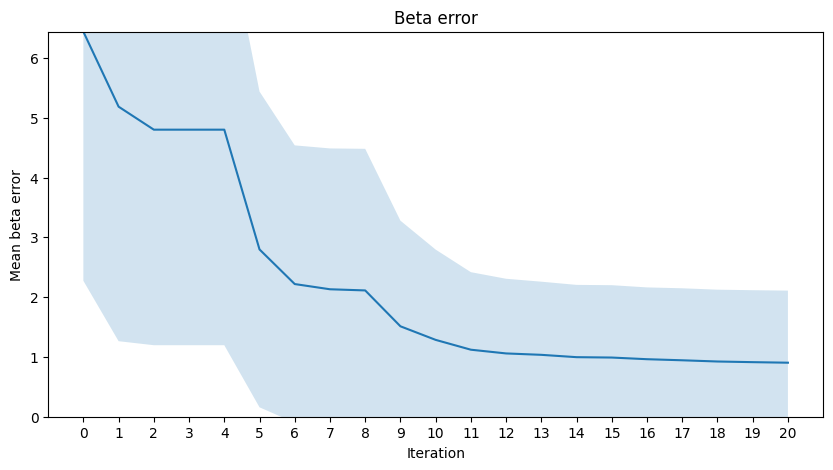

In [70]:
def plot_beta_error_history(beta_history: np.ndarray, beta_true: np.ndarray) -> None:
    """
    Plots mean beta estimation error over EM iterations.
    """
    num_iterations = beta_history.shape[1]
    beta_error_mean_history = np.zeros(num_iterations)
    beta_error_std_history = np.zeros(num_iterations)
    for iteration in range(num_iterations):
        beta_estimated = beta_history[:, iteration]    
        beta_error = np.abs(beta_estimated - beta_true)
        beta_error_mean_history[iteration] = np.mean(beta_error)
        beta_error_std_history[iteration] = np.std(beta_error)

    plt.figure(figsize=(10, 5))
    plt.plot(range(len(beta_error_mean_history)), beta_error_mean_history)
    plt.fill_between(range(len(beta_error_mean_history)),
                     beta_error_mean_history - beta_error_std_history,
                     beta_error_mean_history + beta_error_std_history,
                     alpha = 0.2)
    plt.ylim([0, max(beta_error_mean_history)])
    plt.xticks(range(0,num_iterations))
    plt.xlabel("Iteration")
    plt.ylabel("Mean beta error")
    plt.title("Beta error")
    plt.show()

beta_true = df.groupby("patient_id")["beta_true"].first().values
plot_beta_error_history(beta_history, beta_true)

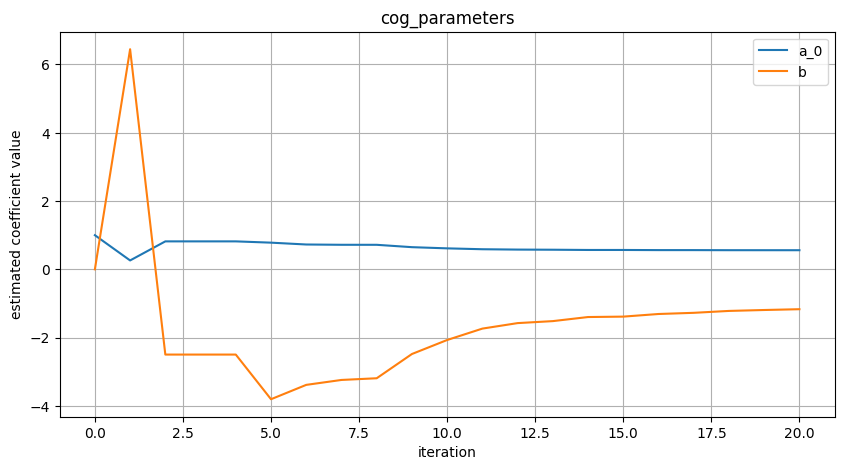

In [71]:
cog_true = np.array([cog_a, cog_b])
def plot_cog_regression_history(cog_history: np.ndarray, cog_true: np.ndarray):
    n_params, num_iterations = cog_history.shape
    
    # cog_error = np.zeros_like(cog_history)
    # for i in range(num_iterations):
    #     cog_error[:,i] = cog_error[:,i] - cog_true
    
    plt.figure(figsize=(10, 5))
    for i in range(n_params):
        label = f"a_{i}" if i < n_params - 1 else "b"
        plt.plot(range(num_iterations), cog_history[i,:], label=label)
    plt.legend()
    plt.xlabel("iteration")
    plt.ylabel("estimated coefficient value")
    plt.title("cog_parameters")
    plt.grid(True)
    plt.show()
    
plot_cog_regression_history(best_em.cog_regression_history, cog_true)

In [72]:
def plot_beta_estimates_on_groundtruth(beta_history: np.ndarray,
                                       beta_true: np.ndarray,
                                       t: np.ndarray,
                                       x_true: np.ndarray,
                                       n_biomarkers: int,
                                       patient_idx: list = None) -> None:
    """
    overlays predicted and true beta (onset) values for selected patients 
    on groundtruth biomarker trajectories. each patient gets a unique color.
    """
    if patient_idx is None:
        patient_idx = [0, 1, 2, 3, 4]

    # deduplicate: assume 3 observations per patient
    beta_pred = beta_history[::3, -1]  # (n_patients,)

    colors = plt.get_cmap("tab10").colors

    fig, ax = plt.subplots(figsize=(10, 4))

    # plot true biomarker trajectories
    for i in range(n_biomarkers):
        ax.plot(t, x_true[i], color="k", alpha=0.5, linewidth=1)

    for i, patient in enumerate(patient_idx):
        color = colors[i % len(colors)]

        beta_t = beta_true[patient]
        beta_p = beta_pred[patient]

        ax.axvline(x=beta_t, color=color, linestyle="-", label=f"true (P{patient})")
        ax.axvline(x=beta_p, color=color, linestyle="--", label=f"pred (P{patient})")

    # remove duplicate legend entries
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

    ax.set_title("Predicted vs. True Onset (Beta) per Patient")
    ax.set_xlabel("Time")
    ax.set_ylabel("Biomarker Value")
    plt.tight_layout()
    plt.show()